# Task 3 — Step 3: SAM — Parameter-Space Stability

Sharpness-Aware Minimisation (Foret et al., 2021), standard **non-adaptive** form, applied to the ERM objective:
$$\min_\theta\;\max_{\|\epsilon\|_2\le\rho}\;\mathcal{L}_{\text{ERM}}(\theta+\epsilon),\qquad \rho=0.05$$
Per source batch (8 images per domain):
1. forward/backward at $\theta$ → $g$; set $\hat\epsilon=\rho\,g/\|g\|_2$ and move to $\theta+\hat\epsilon$;
2. forward/backward at $\theta+\hat\epsilon$ → $g_{\text{SAM}}$; restore $\theta$; **AdamW (lr 1e-4, wd 1e-4, as for ERM)** steps with $g_{\text{SAM}}$.

BatchNorm running statistics stay frozen during **both** passes (BN modules in eval mode). SAM does not remove domain information explicitly; it tests whether a locally stable source solution transfers better to an unseen visual domain. Code: `task3_domain_generalization/src/sam.py`.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from shared.src.seed import set_seed, SEED
from shared.src.pacs_protocol import MAX_EPOCHS, PATIENCE
from shared.src.pacs_data import PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.plotting import use_style, SEQ_CMAP, DIV_CMAP, PALETTE, DOMAIN_COLORS, NEUTRAL, INK_2, color_of, save_show, bar_labels
from shared.src.diagrams import dan_dg_diagram, sam_toy_diagram
from shared.src.losses import compute_mmd
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from task2_domain_adaptation.src.evaluate import evaluate_source_validation, collect_outputs
from task3_domain_generalization.src.train import get_source_loaders, train_dg
from task3_domain_generalization.src.dan_dg import pairwise_source_mmd
from task3_domain_generalization.src.evaluate import (source_separability, fixed_sharpness_batch, sharpness_proxy,
                                                     pairwise_mmd_matrix, random_filter_normalized_direction, loss_along)
DOM_NAMES = {'photo': 'Photo', 'art_painting': 'Art', 'cartoon': 'Cartoon'}

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
CKPT = os.path.join(ROOT, 'task3_domain_generalization', 'checkpoints'); os.makedirs(CKPT, exist_ok=True)
RES = os.path.join(ROOT, 'task3_domain_generalization', 'results'); os.makedirs(RES, exist_ok=True)
T2_CKPT = os.path.join(ROOT, 'task2_domain_adaptation', 'checkpoints')
src_train, src_val = get_source_loaders(DATA, SPLIT)          # Photo / Art / Cartoon only
print('source loaders:', list(src_train), '| Sketch is never loaded in this notebook')

source loaders: ['photo', 'art_painting', 'cartoon'] | Sketch is never loaded in this notebook


## 1. Method at a glance
Left: on a toy 1-D loss (an illustration, not the ResNet), the SAM objective $\max_{|\epsilon|\le\rho}L(w+\epsilon)$ strongly penalises a narrow minimum even when its training loss is lower. Right: the two-pass update actually implemented in `task3_domain_generalization/src/sam.py`.

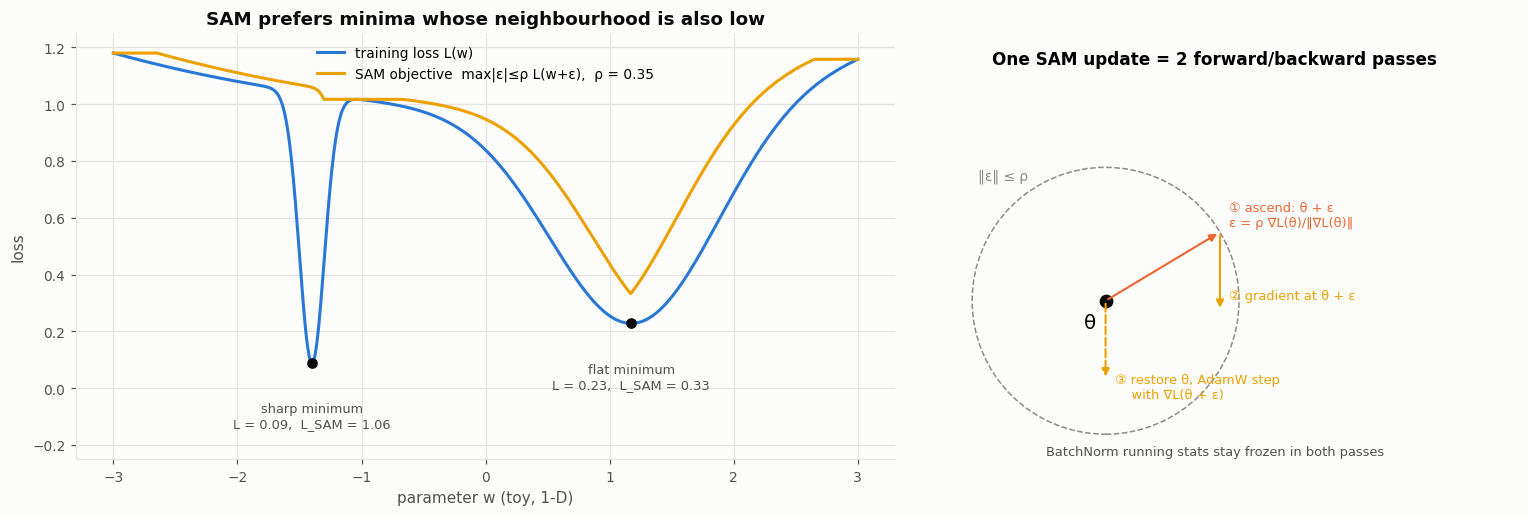

In [2]:
fig = sam_toy_diagram(rho=0.35)
save_show(fig, os.path.join(RES, 'sam_diagram.png'))

## 2. Train SAM

In [3]:
FORCE_TRAIN = True
ckpt_path, hist_path = os.path.join(CKPT, 'sam.pth'), os.path.join(CKPT, 'sam_history.json')
CONFIG = dict(method='sam', rho=0.05, base_optimizer='AdamW', lr=1e-4, wd=1e-4, max_epochs=MAX_EPOCHS, patience=PATIENCE, seed=SEED)
TRAIN_KW = {'method', 'rho', 'lr', 'wd', 'max_epochs', 'patience'}
if FORCE_TRAIN or not os.path.exists(ckpt_path):
    set_seed(SEED)
    out = train_dg(ResNet18Backbone(num_classes=7), src_train, src_val, device, save_path=ckpt_path, **{k: v for k, v in CONFIG.items() if k in TRAIN_KW})
    history, best_epoch, best_f1 = out['history'], out['best_epoch'], out['best_f1']
    json.dump({'config': CONFIG, 'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1}, open(hist_path, 'w'), indent=1)
else:
    meta = json.load(open(hist_path)); history, best_epoch, best_f1 = meta['history'], meta['best_epoch'], meta['best_f1']
model = ResNet18Backbone(num_classes=7).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
erm = ResNet18Backbone(num_classes=7).to(device)
erm.load_state_dict(torch.load(os.path.join(T2_CKPT, 'source_only.pth'), map_location=device, weights_only=True))
erm_hist = json.load(open(os.path.join(T2_CKPT, 'source_only_history.json')))['history']
print(f"selected epoch {best_epoch} | mean source-val macro-F1 {best_f1:.4f}")

[sam] ep  1 | cls 0.851 | L(theta+eps) 1.150 | val F1 mean 0.8858 worst 0.8508 *
[sam] ep  2 | cls 0.268 | L(theta+eps) 0.523 | val F1 mean 0.9303 worst 0.8932 *
[sam] ep  3 | cls 0.171 | L(theta+eps) 0.386 | val F1 mean 0.9335 worst 0.8997 *
[sam] ep  4 | cls 0.138 | L(theta+eps) 0.334 | val F1 mean 0.9402 worst 0.9041 *
[sam] ep  5 | cls 0.081 | L(theta+eps) 0.233 | val F1 mean 0.9436 worst 0.9198 *
[sam] ep  6 | cls 0.065 | L(theta+eps) 0.206 | val F1 mean 0.9482 worst 0.9128 *
[sam] ep  7 | cls 0.048 | L(theta+eps) 0.183 | val F1 mean 0.9541 worst 0.9203 *
[sam] ep  8 | cls 0.035 | L(theta+eps) 0.152 | val F1 mean 0.9260 worst 0.9063
[sam] ep  9 | cls 0.032 | L(theta+eps) 0.147 | val F1 mean 0.9465 worst 0.9192
[sam] ep 10 | cls 0.024 | L(theta+eps) 0.126 | val F1 mean 0.9472 worst 0.9205
[sam] ep 11 | cls 0.023 | L(theta+eps) 0.132 | val F1 mean 0.9402 worst 0.8924
[sam] ep 12 | cls 0.014 | L(theta+eps) 0.098 | val F1 mean 0.9485 worst 0.9092
Early stopping at epoch 12; best epoch

## 3. Training curves (ERM from Task 2 shown for reference)

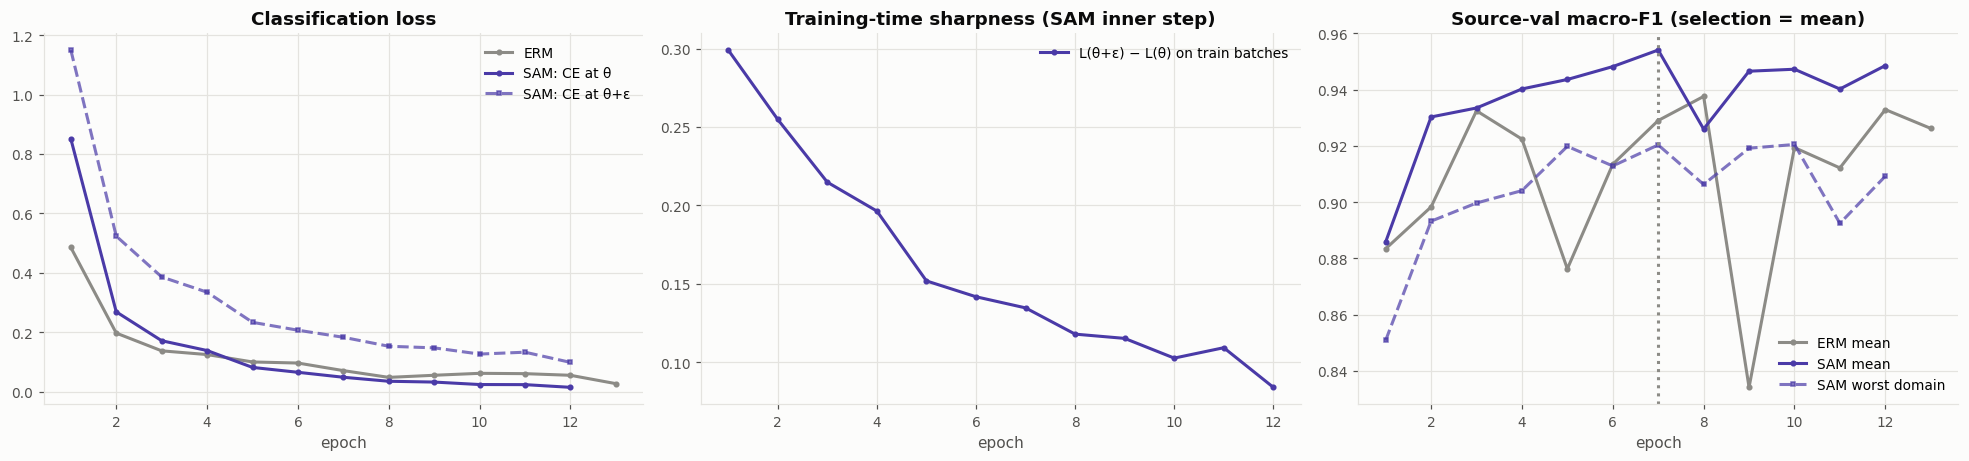

In [4]:
H = history; ep = np.arange(1, len(H['cls_loss']) + 1); e0 = np.arange(1, len(erm_hist['cls_loss']) + 1)
fig, ax = plt.subplots(1, 3, figsize=(18, 4.3))
ax[0].plot(e0, erm_hist['cls_loss'], 'o-', ms=3, color=color_of('ERM'), label='ERM')
ax[0].plot(ep, H['cls_loss'], 'o-', ms=3, color=color_of('SAM'), label='SAM: CE at θ')
ax[0].plot(ep, H['sam_perturbed_loss'], 's--', ms=3, color=color_of('SAM'), alpha=0.7, label='SAM: CE at θ+ε')
ax[0].set_title('Classification loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(ep, np.array(H['sam_perturbed_loss']) - np.array(H['cls_loss']), 'o-', ms=3, color=color_of('SAM'), label='L(θ+ε) − L(θ) on train batches')
ax[1].set_title('Training-time sharpness (SAM inner step)'); ax[1].set_xlabel('epoch'); ax[1].legend()
ax[2].plot(e0, erm_hist['val_mean_f1'], 'o-', ms=3, color=color_of('ERM'), label='ERM mean')
ax[2].plot(ep, H['val_mean_f1'], 'o-', ms=3, color=color_of('SAM'), label='SAM mean')
ax[2].plot(ep, H['val_worst_f1'], 's--', ms=3, color=color_of('SAM'), alpha=0.7, label='SAM worst domain')
ax[2].axvline(best_epoch, color=NEUTRAL, ls=':'); ax[2].set_title('Source-val macro-F1 (selection = mean)'); ax[2].set_xlabel('epoch'); ax[2].legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'sam_training_curves.png'))

## 4. Source-side results and diagnostics (no Sketch)
Per-domain validation performance, the source-domain separability probe (multinomial LR, C = 1, balanced features, seeded 70/30 split; chance = 33.3%), and the common sharpness proxy $\Delta_{\text{sharp}}=L_{\text{val}}(\theta+\epsilon)-L_{\text{val}}(\theta)$ with $\epsilon=0.05\,\nabla L/\|\nabla L\|$ on a fixed batch of 32 validation images per source (seed 6304, eval mode). ERM is listed for reference; notebook 4 reports all three models together.

In [5]:
xb, yb = fixed_sharpness_batch(src_val, per_domain=32, seed=SEED)
xb, yb = xb.to(device), yb.to(device)
rows = {}
for name, net in [('ERM', erm), ('SAM', model)]:
    mt = evaluate_source_validation(net, src_val, device)
    r = {f'{d} F1': 100 * mt[d]['f1'] for d in PACS_SOURCE_DOMAINS}
    r.update({f'{d} acc': 100 * mt[d]['acc'] for d in PACS_SOURCE_DOMAINS})
    r['mean F1'] = np.mean([r[f'{d} F1'] for d in PACS_SOURCE_DOMAINS]); r['worst F1'] = min(r[f'{d} F1'] for d in PACS_SOURCE_DOMAINS)
    r['source separability'] = 100 * source_separability(net, src_val, device, seed=SEED)['source_separability']
    r['Δ_sharp'] = sharpness_proxy(net, xb, yb, rho=0.05)['delta_sharp']
    rows[name] = r
src_tab = pd.DataFrame(rows).T
src_tab.to_csv(os.path.join(RES, 'sam_source_side.csv'))
src_tab.round(3)

,photo F1,art_painting F1,cartoon F1,photo acc,art_painting acc,cartoon acc,mean F1,worst F1,source separability,Δ_sharp
ERM,96.285,91.345,93.642,96.707,91.463,93.177,93.758,91.345,89.701,0.355
SAM,97.154,92.032,97.035,97.605,92.195,96.588,95.407,92.032,88.372,0.091


## 5. Local loss landscape around ERM and SAM (fixed source-validation batch)
All curves use the fixed batch of 32 validation images per source (seed 6304), with the model in eval mode.
- **Left:** loss along the normalised *gradient* direction for step sizes r ∈ [0, 0.15]. The common sharpness proxy is the point r = 0.05.
- **Middle:** loss along three random **filter-normalised** directions (Li et al., 2018), α ∈ [−0.5, 0.5]. Filter normalisation rescales each filter of the direction to that filter's weight norm, so models with different weight scales can be compared.
- **Right:** a 2-D slice on two random filter-normalised directions (13×13 grid) for each model.

These are local, direction-specific views, not a proof that one solution is globally flatter.

C:\Users\moize\AppData\Local\Temp\ipykernel_12924\207593305.py:17: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  a2.plot(alphas, curve, '-', lw=1.8, alpha=0.9, color=color_of(name), ls=['-', '--', ':'][k], label=f'{name}, direction {k + 1}')


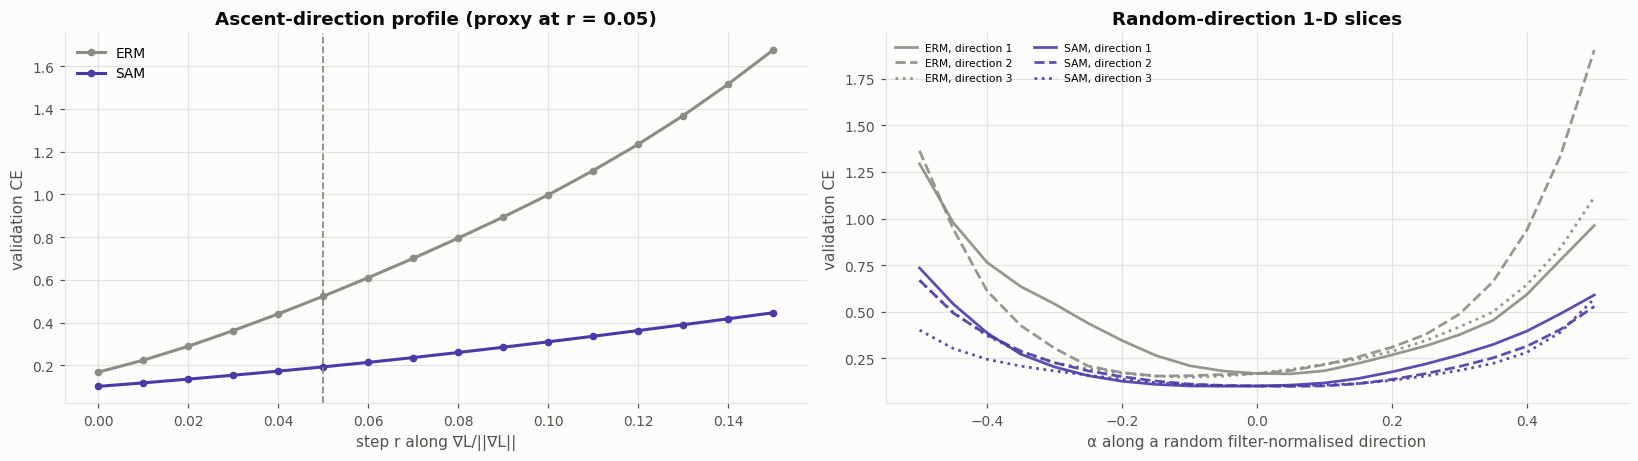

In [6]:
xb, yb = fixed_sharpness_batch(src_val, per_domain=32, seed=SEED); xb, yb = xb.to(device), yb.to(device)
def grad_direction(net):
    net.eval(); net.zero_grad(set_to_none=True)
    torch.nn.functional.cross_entropy(net(xb)[0], yb).backward()
    g = [p.grad.detach().clone() if p.grad is not None else torch.zeros_like(p) for p in net.parameters()]
    n = torch.norm(torch.stack([t.norm() for t in g])); net.zero_grad(set_to_none=True)
    return [t / n for t in g]
radii = np.linspace(0, 0.15, 16); alphas = np.linspace(-0.5, 0.5, 21)
prof, rand1d = {}, {}
for name, net in [('ERM', erm), ('SAM', model)]:
    prof[name] = loss_along(net, xb, yb, [grad_direction(net)], [(r,) for r in radii])
    rand1d[name] = [loss_along(net, xb, yb, [random_filter_normalized_direction(net, seed=SEED + k)], [(a,) for a in alphas]) for k in range(3)]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.3))
for name in prof:
    a1.plot(radii, prof[name], 'o-', ms=4, color=color_of(name), label=name)
    for k, curve in enumerate(rand1d[name]):
        a2.plot(alphas, curve, '-', lw=1.8, alpha=0.9, color=color_of(name), ls=['-', '--', ':'][k], label=f'{name}, direction {k + 1}')
a1.axvline(0.05, color=NEUTRAL, ls='--', lw=1.2); a1.set_xlabel('step r along ∇L/||∇L||'); a1.set_ylabel('validation CE'); a1.set_title('Ascent-direction profile (proxy at r = 0.05)'); a1.legend()
a2.set_xlabel('α along a random filter-normalised direction'); a2.set_ylabel('validation CE'); a2.set_title('Random-direction 1-D slices'); a2.legend(fontsize=7, ncol=2)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'sam_vs_erm_1d_landscape.png'))

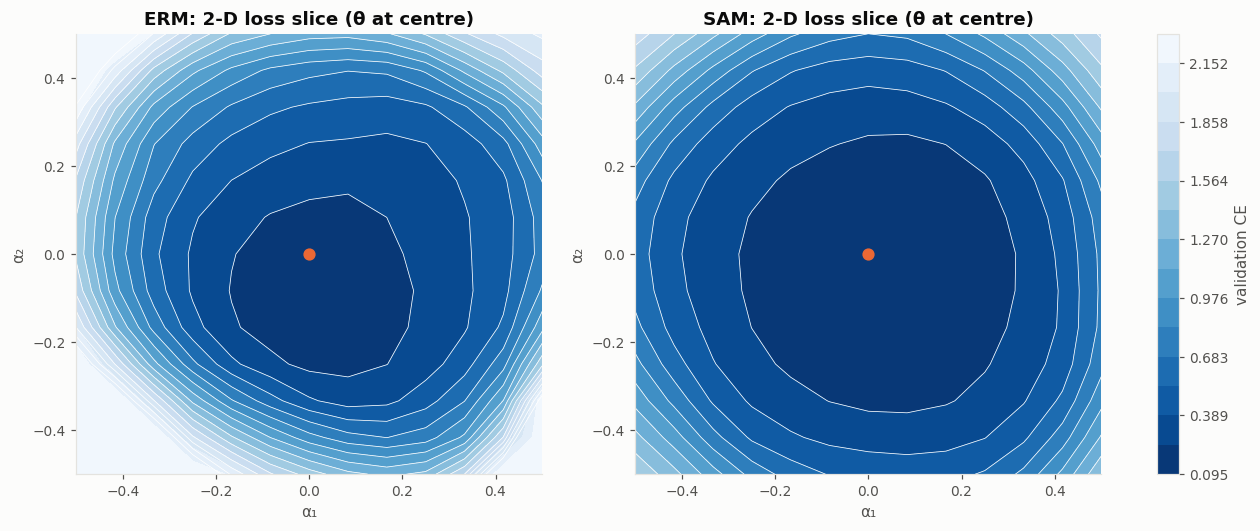

In [7]:
grid = np.linspace(-0.5, 0.5, 13); coords = [(a, b) for b in grid for a in grid]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
surf = {}
for name, net in [('ERM', erm), ('SAM', model)]:
    dirs = [random_filter_normalized_direction(net, seed=SEED + 10), random_filter_normalized_direction(net, seed=SEED + 11)]
    surf[name] = loss_along(net, xb, yb, dirs, coords).reshape(len(grid), len(grid))
levels = np.linspace(min(s.min() for s in surf.values()), np.percentile(np.concatenate([s.ravel() for s in surf.values()]), 95), 16)
for ax, (name, Z) in zip(axes, surf.items()):
    cs = ax.contourf(grid, grid, np.clip(Z, None, levels[-1]), levels=levels, cmap='Blues_r')
    ax.contour(grid, grid, Z, levels=levels, colors='white', linewidths=0.5)
    ax.plot(0, 0, 'o', color=PALETTE[1], ms=7); ax.set_title(f'{name}: 2-D loss slice (θ at centre)'); ax.set_xlabel('α₁'); ax.set_ylabel('α₂'); ax.grid(False)
fig.colorbar(cs, ax=axes, fraction=0.025, label='validation CE'); save_show(fig, os.path.join(RES, 'sam_vs_erm_2d_landscape.png'))

## 6. Which source domain is sharpest?
The same proxy, computed separately on each domain's 32 fixed validation images.

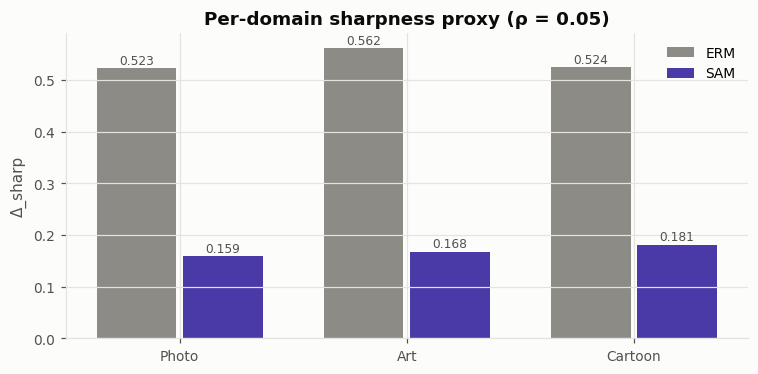

,ERM,SAM
Photo,0.5230,0.1587
Art,0.5618,0.1676
Cartoon,0.5245,0.1813


In [8]:
xs_all, ys_all = xb.split(32), yb.split(32)
per_dom = pd.DataFrame({name: {DOM_NAMES[d]: sharpness_proxy(net, xd, yd, rho=0.05)['delta_sharp'] for d, xd, yd in zip(PACS_SOURCE_DOMAINS, xs_all, ys_all)}
                        for name, net in [('ERM', erm), ('SAM', model)]})
fig, a = plt.subplots(figsize=(8, 3.6)); x = np.arange(3); w = 0.38
for k, name in enumerate(per_dom.columns):
    b = a.bar(x + (k - 0.5) * w, per_dom[name], w * 0.92, color=color_of(name), label=name); bar_labels(a, b, fmt='{:.3f}', offset=0.002)
a.set_xticks(x); a.set_xticklabels(per_dom.index); a.set_ylabel('Δ_sharp'); a.set_title('Per-domain sharpness proxy (ρ = 0.05)'); a.legend()
save_show(fig, os.path.join(RES, 'sam_per_domain_sharpness.png'))
per_dom.round(4)